# Complete Library Showcase

This notebook provides a comprehensive overview of every module and method available in the library. We will use the **PEMS-BAY** traffic dataset to demonstrate real-world utility.


## 1. Setup and Imports


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Standard way to add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_path = os.path.join(project_root, 'src')

if src_path not in sys.path:
    sys.path.insert(0, src_path)

from src.data.loaders import load_dataset
from src.matrix_generation import (
    PearsonCorrelationGenerator,
    PartialCorrelationGenerator,
    DTWGenerator,
    GrangerCausalityGenerator,
    MutualInformationGenerator,
    EmbeddingCosineGenerator
)
from src.sparcification import (
    MatrixConstructionPipeline,
    TopKRowSparsifier,
    MutualKNNSparsifier,
    MSTSparsifier,
    PMFGSparsifier,
    RowL1Normalizer,
    RowSoftmaxNormalizer
)
from src.hybrid import (
    WeightedAverageFuser,
    ElementWiseMaxFuser,
    ElementWiseMinFuser,
    RankAverageFuser,
    SNFDiffusionFuser
)
from src.utils.visualization import (
    plot_adjacency_matrix_heatmap,
    compare_adjacency_matrices_heatmap,
    plot_edge_weight_distribution,
    plot_spectral_analysis,
    plot_adjacency_diff,
    plot_matrix_spy,
    plot_node_neighborhood,
    plot_node_time_series
)
from src.utils.graph_metrics import calculate_graph_metrics

print("Imports successful!")


ModuleNotFoundError: No module named 'src'

## 2. Dataset Loading
We load a slice of the PEMS-BAY dataset. For performance and clarity, we'll sub-sample to 50 nodes and 1000 timesteps.


Attempting to load data with shape [52116, 325, 3]...
Data loaded successfully as a numpy.memmap object.
Data shape: (52116, 325, 3)
Working data shape: (2016, 50, 3)


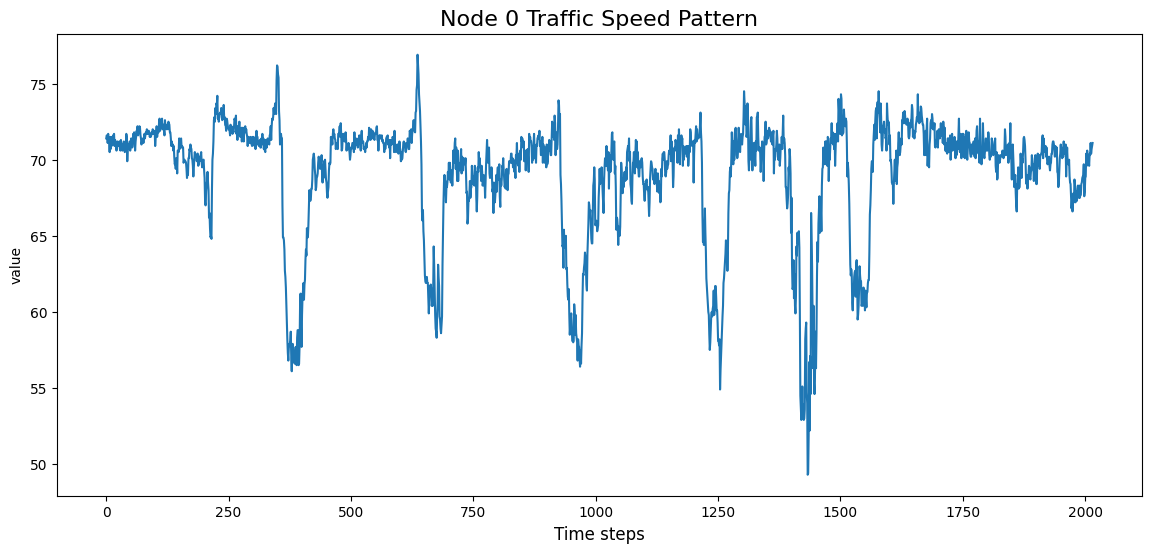

In [ ]:
# Load PEMS-BAY
dataset_root = '../data/PEMS-BAY/'
data_dict = load_dataset(dataset_root, load_adj_matrix=False, verbose=False)
raw_data = data_dict['data']

# Subset: [Timesteps, Nodes, Features]
data = np.array(raw_data[:2016, :50, :])
print(f"Working data shape: {data.shape}")

# Visualize a few time series
plot_node_time_series(data, node_index=0, title="Node 0 Traffic Speed Pattern")


## 3. Matrix Generation Suite
In this section, we showcase all 6 statistical and neural generation methods.


Running Pearson Generator...
Running Partial Corr Generator...
Running Granger Generator...


c:\Work\Minerva\gnns\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Running Mutual Info Generator...
Running Embedding Generator...


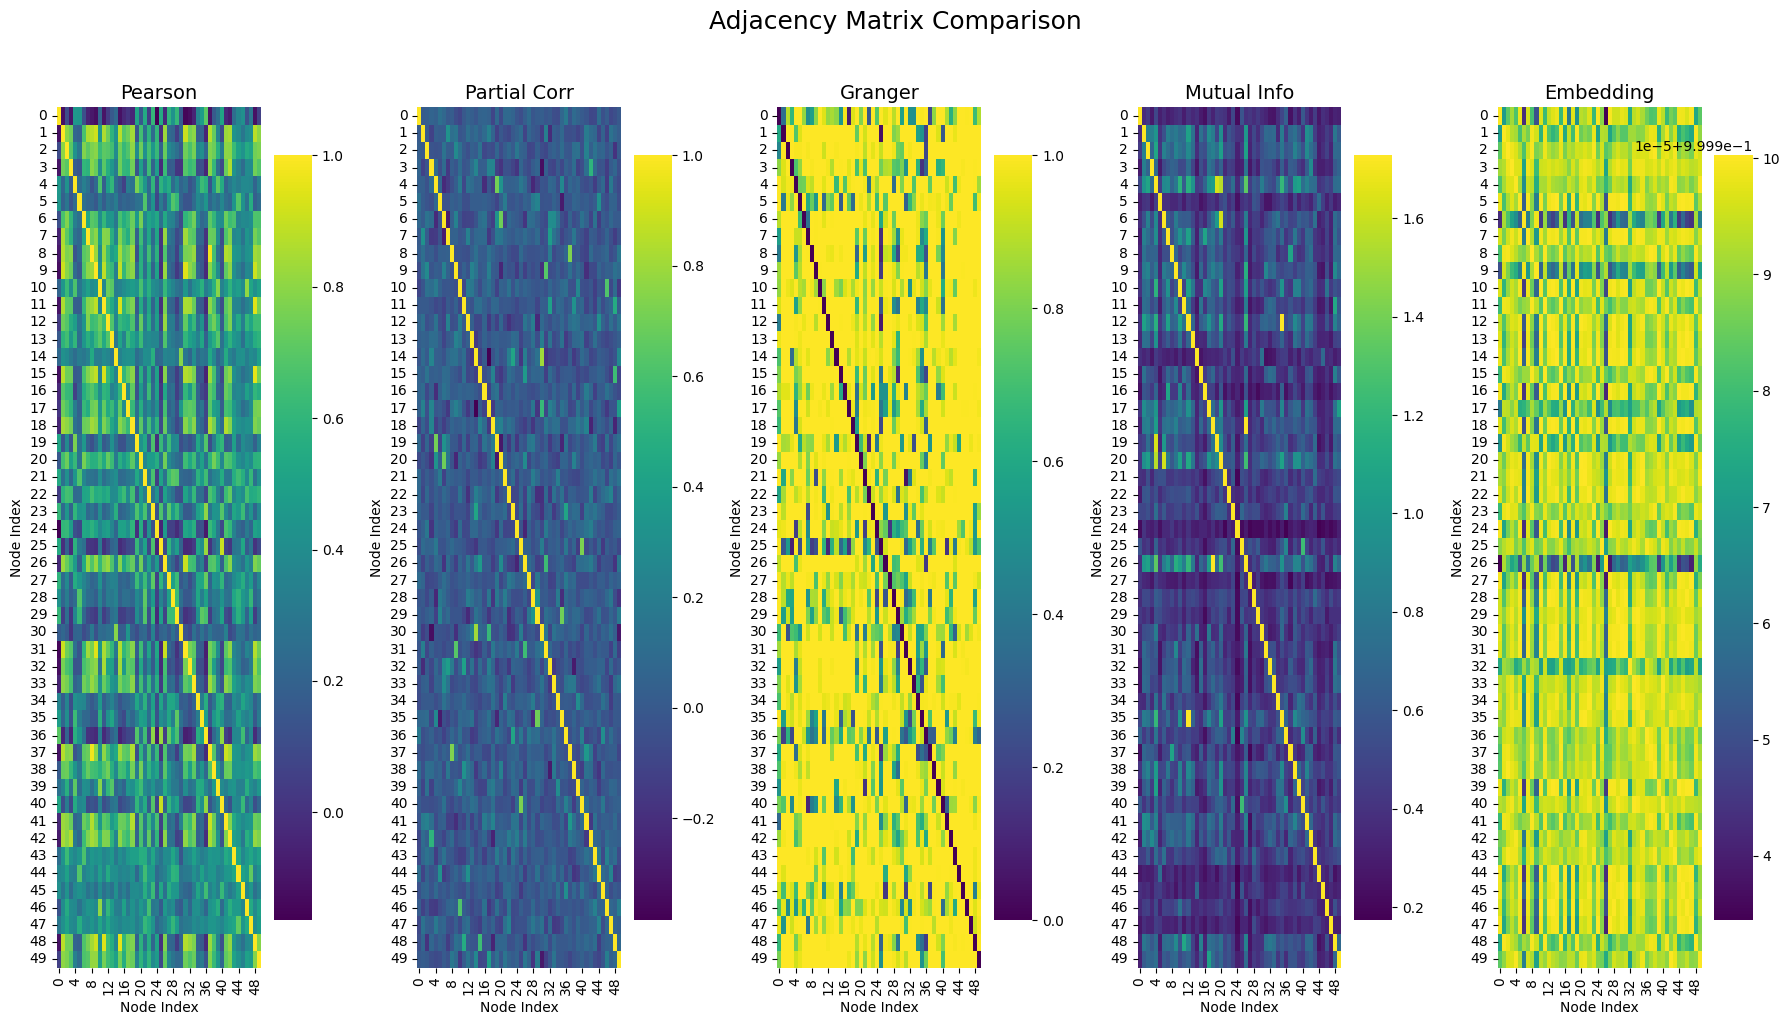

In [ ]:
# Initialize all generators
generators = [
    ("Pearson", PearsonCorrelationGenerator()),
    ("Partial Corr", PartialCorrelationGenerator()),
   # ("DTW", DTWGenerator()),
    ("Granger", GrangerCausalityGenerator(maxlag=3)),
    ("Mutual Info", MutualInformationGenerator(n_neighbors=3)),
    ("Embedding", EmbeddingCosineGenerator(hidden_dim=16, embedding_dim=16))
]

generated_matrices = {}

for name, gen in generators:
    print(f"Running {name} Generator...")
    generated_matrices[name] = gen.generate(data)

# Compare the results visually
compare_adjacency_matrices_heatmap(
    list(generated_matrices.values()), 
    list(generated_matrices.keys()),
    figsize=(18, 18)
)


## 4. Sparsification & Normalization Suite
We now demonstrate the 4 sparsifiers, showing how they refine raw similarity into structural adjacency.


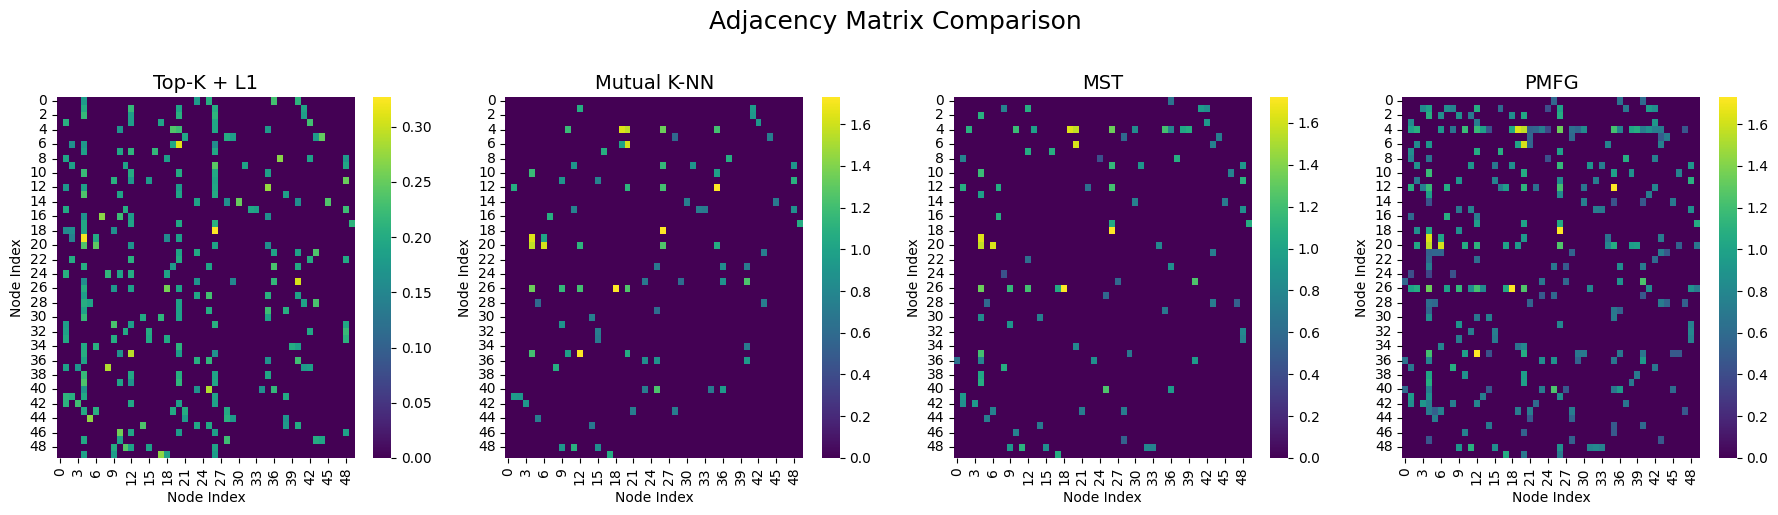

In [ ]:
# Sample base matrix (Mutual Information)
base_sim = generated_matrices["Mutual Info"]

# 1. Top-K Sparsification + L1 Normalization (Standard Pipeline)
pipe_topk = MatrixConstructionPipeline(
    sparsifiers=[TopKRowSparsifier(k_per_node=5)],
    normalizers=[RowL1Normalizer()]
)
adj_topk = pipe_topk.run(base_sim, k=150)

# 2. Mutual K-NN (Forces Symmetry)
pipe_mknn = MatrixConstructionPipeline(sparsifiers=[MutualKNNSparsifier(k_per_node=5)])
adj_mknn = pipe_mknn.run(base_sim, k=150)

# 3. Minimum Spanning Tree (Guarantees Connectivity)
pipe_mst = MatrixConstructionPipeline(sparsifiers=[MSTSparsifier()])
adj_mst = pipe_mst.run(base_sim, k=150)

# 4. PMFG (Planar constraints)
pipe_pmfg = MatrixConstructionPipeline(sparsifiers=[PMFGSparsifier()])
adj_pmfg = pipe_pmfg.run(base_sim, k=150)

# Visualize structural differences
compare_adjacency_matrices_heatmap(
    [adj_topk, adj_mknn, adj_mst, adj_pmfg],
    ["Top-K + L1", "Mutual K-NN", "MST", "PMFG"],
    figsize=(18, 5)
)


## 5. Hybrid Matrix Fusion
Fusing multiple perspectives (Linear vs Non-linear vs Causal). We demonstrate the unsupervised fusers.


Running Weighted Avg Fuser...
Running ElementMax Fuser...
Running Rank Avg Fuser...
Running SNF Diffusion Fuser...


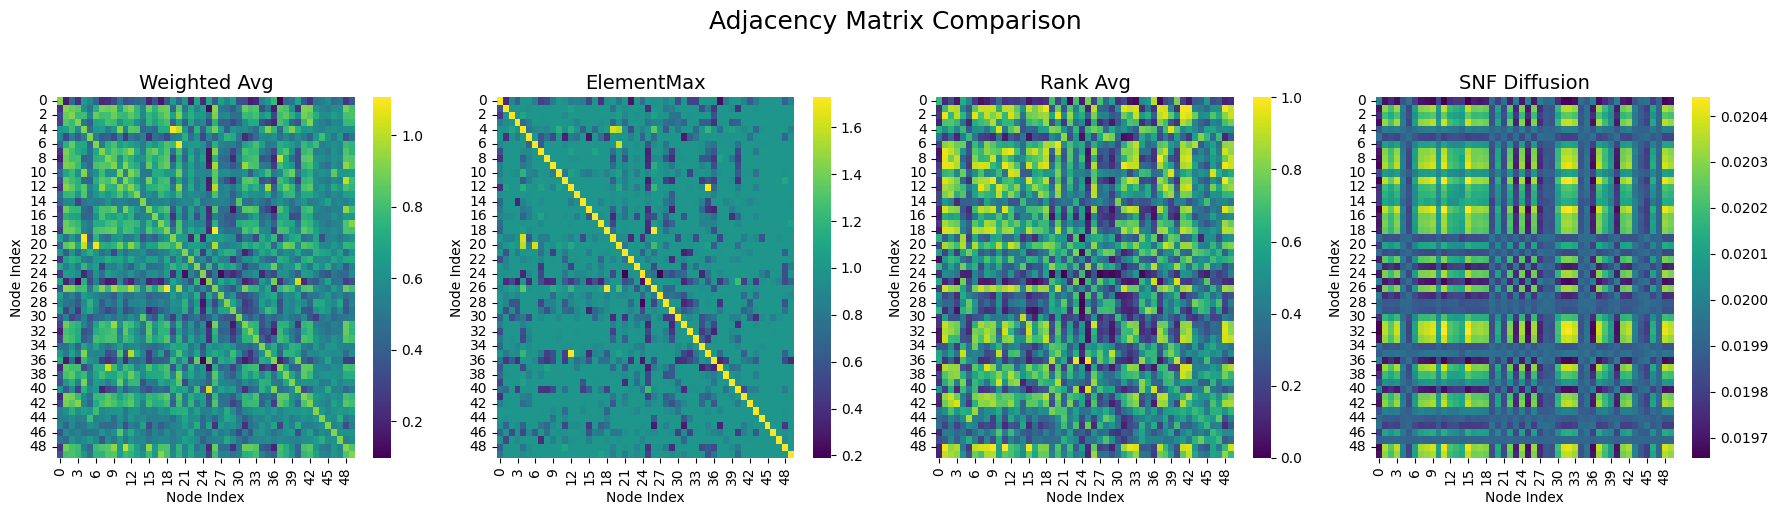

In [ ]:
# Select matrices to fuse
to_fuse = [
    generated_matrices["Pearson"],
    generated_matrices["Granger"],
    generated_matrices["Mutual Info"]
]

fusers = [
    ("Weighted Avg", WeightedAverageFuser(weights=[0.4, 0.3, 0.3])),
    ("ElementMax", ElementWiseMaxFuser()),
    ("Rank Avg", RankAverageFuser()),
    ("SNF Diffusion", SNFDiffusionFuser(k_neighbors=5, n_iterations=10))
]

fused_matrices = {}
for name, fuser in fusers:
    print(f"Running {name} Fuser...")
    fused_matrices[name] = fuser.fuse(to_fuse)

# Compare fusion strategies
compare_adjacency_matrices_heatmap(
    list(fused_matrices.values()),
    list(fused_matrices.keys()),
    figsize=(18, 5)
)


## 6. Advanced Diagnostics & Analysis
Deep dive into the properties of a 'Final' research-ready matrix (SNF Fused).


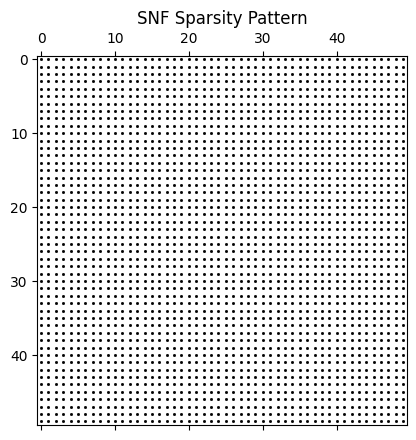

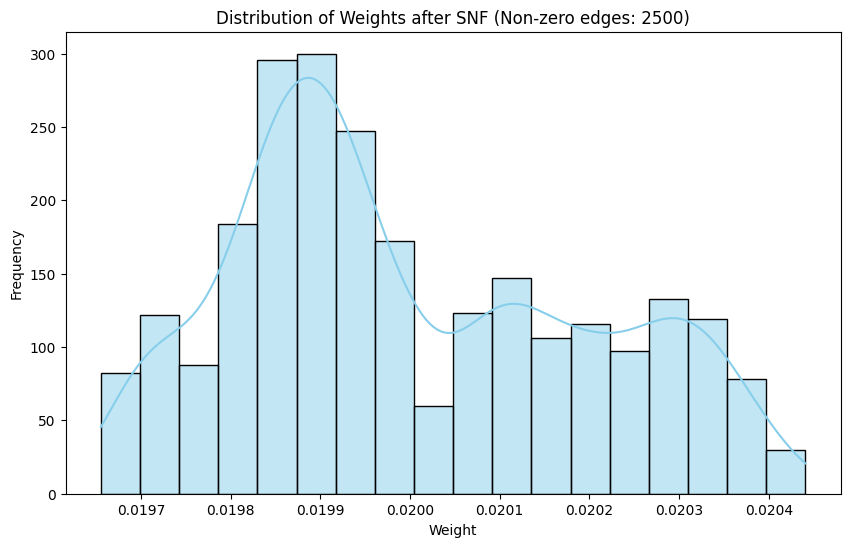

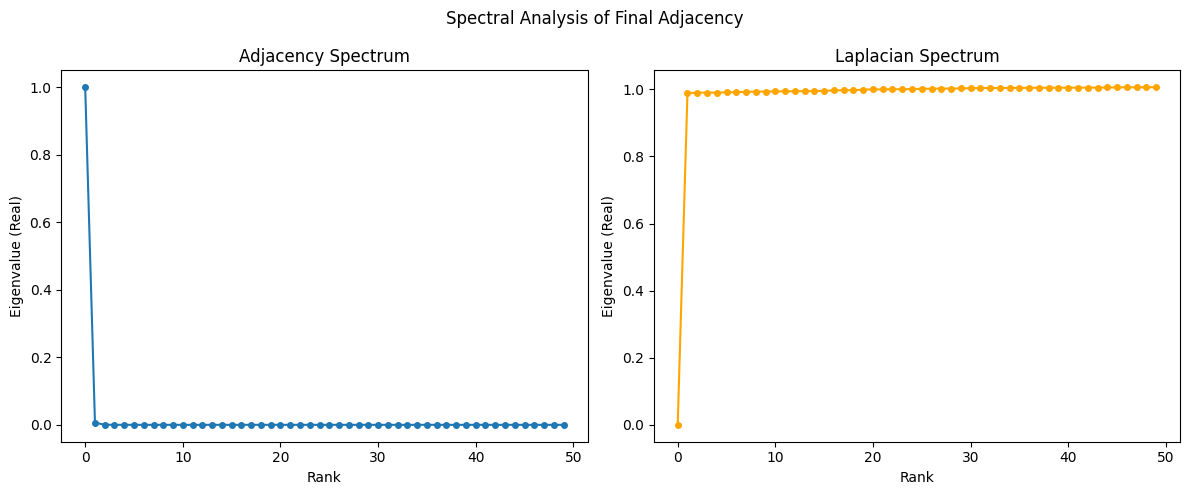

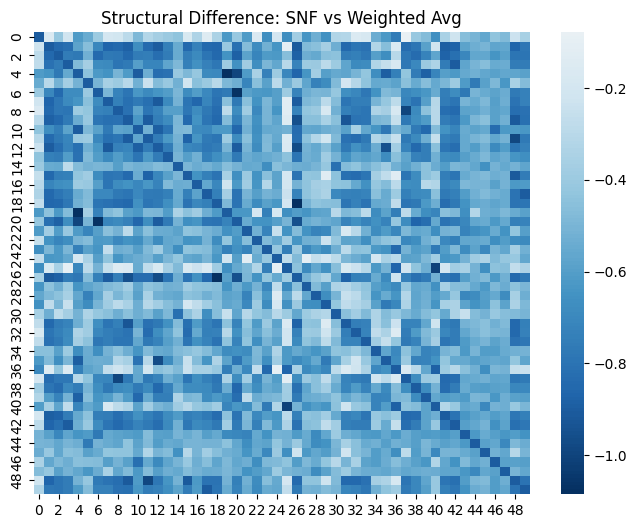

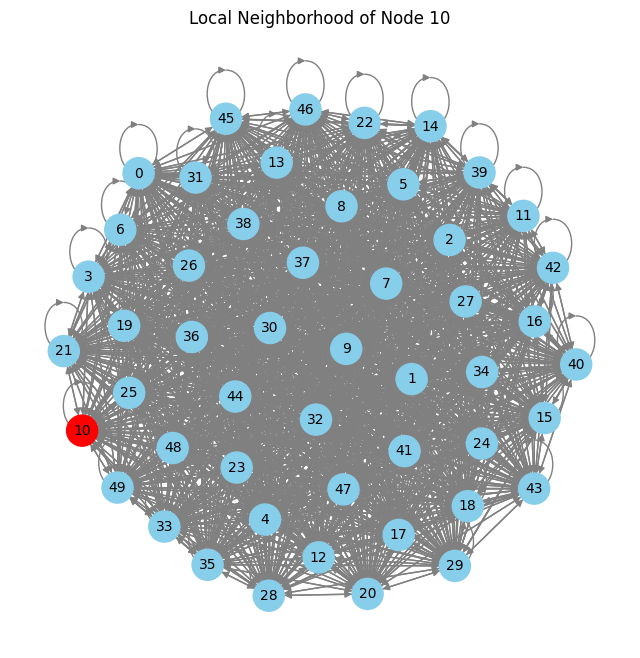

In [ ]:
final_adj = fused_matrices["SNF Diffusion"]

# A. Sparsity Pattern (Spy Plot)
plot_matrix_spy(final_adj, title="SNF Sparsity Pattern")

# B. Edge Weight Distribution
plot_edge_weight_distribution(final_adj, title="Distribution of Weights after SNF")

# C. Spectral Analysis (Eigenvalues)
plot_spectral_analysis(final_adj, title="Spectral Analysis of Final Adjacency")

# D. Adjacency Difference
# Let's see what SNF changed compared to a simple average
simple_avg = fused_matrices["Weighted Avg"]
plot_adjacency_diff(final_adj, simple_avg, title="Structural Difference: SNF vs Weighted Avg")

# E. Local Neighborhood Exploration
# Looking at Node 10 and its surroundings
plot_node_neighborhood(final_adj, node_idx=10, title="Local Neighborhood of Node 10")


## 7. Statistical Metrics Comparison
Finally, we generate a report of graph properties for different configurations.


In [ ]:
import pandas as pd
from IPython.display import display

test_configs = {
    "MI (Base)": generated_matrices["Mutual Info"],
    "MI (Top-K)": adj_topk,
    "MI (MST)": adj_mst,
    "SNF Fused": final_adj
}

metric_results = []
for name, matrix in test_configs.items():
    m = calculate_graph_metrics(matrix, directed=True)
    m['Method'] = name
    metric_results.append(m)

df = pd.DataFrame(metric_results).set_index('Method')
# Display key metrics
display(df[['num_nodes', 'density', 'sparsity', 'spectral_gap', 'num_components', 'is_connected']])


,num_nodes,density,sparsity,spectral_gap,num_components,is_connected
Method,,,,,,
MI (Base),50,1.020408,0.0000,23.169867,1,True
MI (Top-K),50,0.102041,0.9000,0.316829,14,True
MI (MST),50,0.040000,0.9608,1.453548,1,True
SNF Fused,50,1.020408,0.0000,0.993853,1,True
